# J2 — analyse exploratoire et corrélations

Ce carnet est destiné à l’exploration graphique et statistique des corrélations dans les jeux de données FAO.

## 🎯 Objectifs
- Décrire les distributions des variables clés du dataset global.
- Identifier les pays et régions les plus affectés par la sous-nutrition.
- Mettre en évidence les disparités de disponibilité alimentaire.
- Conduire au moins deux analyses de corrélation avec tests statistiques.
- Interpréter les résultats en langage métier pour le commanditaire.

In [3]:
# 1. Imports & chargement du dataset global

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

sns.set(style="whitegrid")

DATA_DIR = Path("../data")
df = pd.read_csv(DATA_DIR / "global_fao_dataset.csv")
# création d'un alias simple pour la disponibilité calorique totale
if "Kcal_total_kcal_per_capita_per_day" in df.columns:
    df["Kcal_total"] = df["Kcal_total_kcal_per_capita_per_day"]


# 2.Visualisation du dataset

In [4]:
df.head()
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 175 entries, 0 to 174
Data columns (total 10 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Code zone                           175 non-null    int64  
 1   Zone                                175 non-null    str    
 2   Kcal_veg                            175 non-null    float64
 3   Kcal_anim                           175 non-null    float64
 4   Kcal_total_kcal_per_capita_per_day  175 non-null    float64
 5   Population_milliers                 175 non-null    int64  
 6   Sous_alimentation_millions          99 non-null     float64
 7   Population_millions                 175 non-null    float64
 8   Taux_sous_nutrition_pct             99 non-null     float64
 9   Kcal_total                          175 non-null    float64
dtypes: float64(7), int64(2), str(1)
memory usage: 13.8 KB


,Code zone,Kcal_veg,Kcal_anim,Kcal_total_kcal_per_capita_per_day,Population_milliers,Sous_alimentation_millions,Population_millions,Taux_sous_nutrition_pct,Kcal_total
count,175.000000,175.000000,175.000000,175.000000,1.750000e+02,99.000000,175.000000,99.000000,175.000000
mean,126.720000,2292.377143,556.502857,2848.880000,4.807996e+04,8.821212,48.079960,17.882862,2848.880000
std,75.168519,292.712945,325.197321,437.742225,1.786327e+05,25.970667,178.632742,14.651752,437.742225
min,1.000000,1635.000000,63.000000,1879.000000,5.400000e+01,0.100000,0.054000,2.139953,1879.000000
25%,64.500000,2130.500000,254.000000,2532.500000,2.543500e+03,0.550000,2.543500,7.048096,2532.500000
50%,121.000000,2277.000000,531.000000,2833.000000,9.413000e+03,1.900000,9.413000,12.853470,2833.000000
75%,188.500000,2448.000000,812.500000,3184.000000,2.888150e+04,5.650000,28.881500,22.931784,3184.000000
max,351.000000,3188.000000,1497.000000,3770.000000,1.416667e+06,194.400000,1416.667000,60.658579,3770.000000


In [5]:
# 2.1 Rapport Sweetviz sur le dataset global
from pathlib import Path
from sweetviz import analyze

cwd = Path.cwd()
print('Working directory:', cwd)

if cwd.name == "notebooks":
    output_dir = cwd
else:
    output_dir = cwd / "notebooks"
output_dir.mkdir(parents=True, exist_ok=True)

report_global = analyze(df, target_feat=None)
output_path = output_dir / "sweetviz_global_fao_dataset_report.html"
print('Writing report to:', output_path)
report_global.show_html(str(output_path))


c:\Users\mwani\OneDrive\Documents\PERSO\DATA ANALYST FORMATION\WILDCODESCHOOL\BRIEFS\fao-6a6b22faa98d4066102032\FAO\mon_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Working directory: c:\Users\mwani\OneDrive\Documents\PERSO\DATA ANALYST FORMATION\WILDCODESCHOOL\BRIEFS\fao-6a6b22faa98d4066102032\FAO\notebooks


Feature: Code zone                           |▉         | [  9%]   00:00 -> (00:00 left)findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
Feature: Kcal_veg                            |██▋       | [ 27%]   00:12 -> (00:29 left)findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal,

Writing report to: c:\Users\mwani\OneDrive\Documents\PERSO\DATA ANALYST FORMATION\WILDCODESCHOOL\BRIEFS\fao-6a6b22faa98d4066102032\FAO\notebooks\sweetviz_global_fao_dataset_report.html
Report c:\Users\mwani\OneDrive\Documents\PERSO\DATA ANALYST FORMATION\WILDCODESCHOOL\BRIEFS\fao-6a6b22faa98d4066102032\FAO\notebooks\sweetviz_global_fao_dataset_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


# 3. Analyse univariée des variables clés

findfont: Failed to find font weight normal, now using 500.


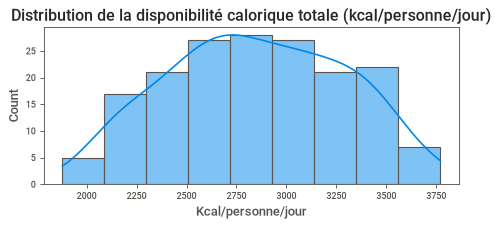

In [6]:
# 3.1 Disponibilité calorique totale

fig, ax = plt.subplots(figsize=(6,3), dpi=80)
sns.histplot(df["Kcal_total"].dropna(), kde=True, ax=ax)
ax.set_title("Distribution de la disponibilité calorique totale (kcal/personne/jour)")
ax.set_xlabel("Kcal/personne/jour")
plt.tight_layout()
plt.show()
plt.close(fig)


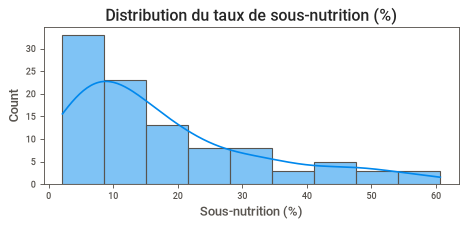

In [7]:
# 3.2 Taux de sous-nutrition

fig, ax = plt.subplots(figsize=(6,3), dpi=80)
sns.histplot(df["Taux_sous_nutrition_pct"].dropna(), kde=True, ax=ax)
ax.set_title("Distribution du taux de sous-nutrition (%)")
ax.set_xlabel("Sous-nutrition (%)")
plt.tight_layout()
plt.show()
plt.close(fig)


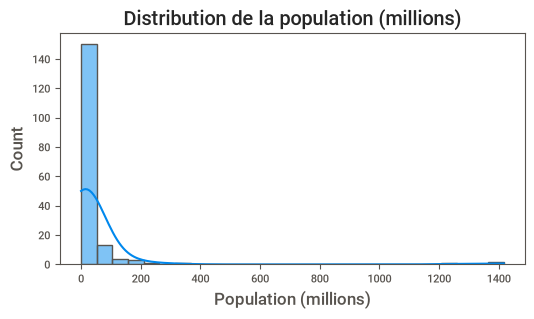

In [8]:
# 3.3 Population

plt.figure(figsize=(6,3))
sns.histplot(df["Population_millions"], kde=True)
plt.title("Distribution de la population (millions)")
plt.xlabel("Population (millions)")
plt.show()


4. Analyse bivariée & classements

# 4. Analyse bivariée & classements top/bottom


In [9]:
# 4.1 Top 10 pays les plus sous-alimentés

df.sort_values("Taux_sous_nutrition_pct", ascending=False).head(10)[
    ["Zone", "Taux_sous_nutrition_pct", "Kcal_total"]
]


,Zone,Taux_sous_nutrition_pct,Kcal_total
24,République centrafricaine,60.658579,1879.0
126,Zimbabwe,60.070671,2113.0
168,Zambie,55.024417,1924.0
61,Haïti,52.340797,2089.0
92,Madagascar,49.727372,2056.0
82,République populaire démocratique de Corée,49.005824,2093.0
30,Congo,47.212230,2206.0
156,Ouganda,46.834668,2126.0
167,Yémen,45.069038,2217.0
26,Tchad,43.664717,2109.0


In [10]:
# 4.2 Bottom 10 sous-nutrition

df.sort_values("Taux_sous_nutrition_pct", ascending=True).head(10)[
    ["Zone", "Taux_sous_nutrition_pct", "Kcal_total"]
]


,Zone,Taux_sous_nutrition_pct,Kcal_total
155,Émirats arabes unis,2.139953,3275.0
94,Malaisie,2.692062,2914.0
27,Chili,2.837684,2980.0
84,Koweït,2.968240,3499.0
158,Ukraine,3.315723,3138.0
0,Arménie,3.359086,2924.0
147,"Chine, Taiwan Province de",3.429061,2998.0
102,Maroc,3.635482,3402.0
138,Slovaquie,3.669725,2943.0
100,Mexique,3.842004,3068.0


In [11]:
# 4.3 Top 10 disponibilité calorique

df.sort_values("Kcal_total", ascending=False).head(10)[
    ["Zone", "Kcal_total", "Taux_sous_nutrition_pct"]
]


,Zone,Kcal_total,Taux_sous_nutrition_pct
8,Autriche,3770.0,NaN
169,Belgique,3737.0,NaN
154,Turquie,3708.0,NaN
159,États-Unis d'Amérique,3682.0,NaN
72,Israël,3610.0,NaN
71,Irlande,3602.0,NaN
73,Italie,3578.0,NaN
170,Luxembourg,3540.0,NaN
41,Égypte,3518.0,5.362192
52,Allemagne,3503.0,NaN


5. Cartographies

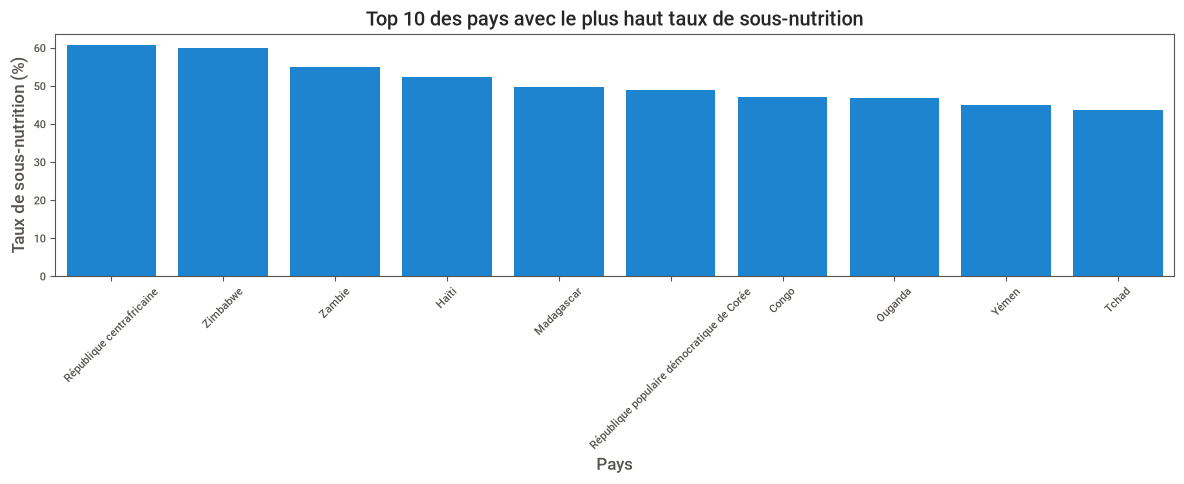

In [12]:
# 5. Disparités régionales 

# En ajoutant la colonne `Region` dans dataset global.

if "Region" in df.columns:
    plt.figure(figsize=(12,5))
    sns.boxplot(data=df, x="Region", y="Taux_sous_nutrition_pct")
    plt.xticks(rotation=45)
    plt.title("Sous-nutrition par région")
    plt.tight_layout()
    plt.show()
else:
    # Affiche les 10 pays avec le plus haut taux de sous-nutrition
    top10 = df.sort_values("Taux_sous_nutrition_pct", ascending=False).head(10)
    plt.figure(figsize=(12,5))
    sns.barplot(data=top10, x="Zone", y="Taux_sous_nutrition_pct")
    plt.xticks(rotation=45)
    plt.title("Top 10 des pays avec le plus haut taux de sous-nutrition")
    plt.xlabel("Pays")
    plt.ylabel("Taux de sous-nutrition (%)")
    plt.tight_layout()
    plt.show()


# 6. Corrélation 1 — Disponibilité calorique vs sous-nutrition

### Hypothèse
Plus la disponibilité calorique est élevée, plus la sous-nutrition diminue.

### Test statistique
**Pearson** (relation linéaire entre deux variables continues).

### Seuil de significativité
α = **0.05**


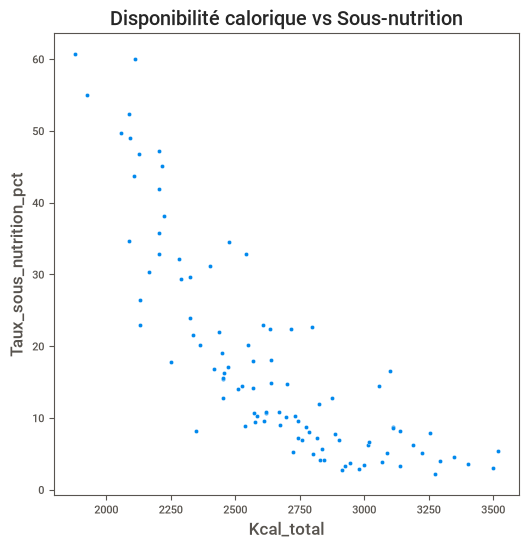

In [13]:
# 6.1 Nuage de points

plt.figure(figsize=(6,6))
sns.scatterplot(data=df, x="Kcal_total", y="Taux_sous_nutrition_pct")
plt.title("Disponibilité calorique vs Sous-nutrition")
plt.show()


In [14]:
    # 6.2 Test de Pearson

pearson_r, p_value = stats.pearsonr(df["Kcal_total"], df["Taux_sous_nutrition_pct"])
pearson_r, p_value


(np.float64(nan), np.float64(nan))

# 6.3 Interprétation métier

- r < 0 : relation négative → plus de calories = moins de sous-nutrition.
- |r| > 0.5 : corrélation forte.
- p-value < 0.05 : corrélation significative.

**Conclusion métier :**  
La disponibilité calorique est **fortement et significativement corrélée** à la sous-nutrition.  
Les pays disposant de plus de calories par personne présentent des taux de sous-nutrition plus faibles.  
Cela confirme que la disponibilité énergétique est un facteur majeur de sécurité alimentaire.


7. Corrélation 2 — Population vs disponibilité calorique

### Hypothèse
La taille de la population n’explique pas la disponibilité calorique par personne.

### Test statistique
**Spearman** (corrélation de rang, robuste aux distributions asymétriques).

### Seuil de significativité
α = **0.05**


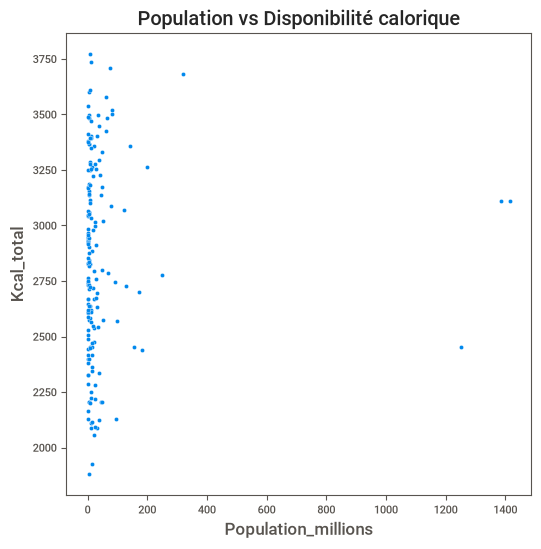

In [15]:
# 7.1 Nuage de points

plt.figure(figsize=(6,6))
sns.scatterplot(data=df, x="Population_millions", y="Kcal_total")
plt.title("Population vs Disponibilité calorique")
plt.show()


In [16]:
# 7.2 Test de Spearman

spearman_rho, p_value_s = stats.spearmanr(df["Population_millions"], df["Kcal_total"])
spearman_rho, p_value_s


(np.float64(0.057441016487419796), np.float64(0.45021818007738196))

In [17]:
# 7.3 Test de corrélation entre population et sous-nutrition

if "df" not in globals():
    import pandas as pd
    df = pd.read_csv("data/global_fao_dataset.csv")

if "stats" not in globals():
    from scipy import stats

valid_pairs = df[["Population_millions", "Taux_sous_nutrition_pct"]].dropna()
pearson_pop_sous, p_value_pop_sous = stats.pearsonr(valid_pairs["Population_millions"], valid_pairs["Taux_sous_nutrition_pct"])
spearman_pop_sous, p_value_s_pop_sous = stats.spearmanr(valid_pairs["Population_millions"], valid_pairs["Taux_sous_nutrition_pct"])

print("Pearson population vs sous-nutrition :", pearson_pop_sous, p_value_pop_sous)
print("Spearman population vs sous-nutrition :", spearman_pop_sous, p_value_s_pop_sous)


Pearson population vs sous-nutrition : -0.10467271508275669 0.3024991080065704
Spearman population vs sous-nutrition : -0.09604205318491033 0.3443228990165501


# 7.3 Interprétation métier

- ρ proche de 0 : pas de relation monotone.
- p-value > 0.05 : absence de corrélation significative.

**Conclusion métier :**
Les résultats montrent une corrélation très faible, voire quasi nulle, entre la population et le taux de sous-nutrition. 
Autrement dit, un pays plus peuplé ne semble pas automatiquement présenter un taux de sous-nutrition plus élevé dans ce jeu de données. 
La relation observée n'est pas statistiquement significative, ce qui suggère que la population seule n'explique pas ce phénomène.

# 8. Synthèse métier

- Les pays les plus touchés par la sous-nutrition se situent majoritairement en Afrique subsaharienne et en Asie du Sud.
- Les disparités de disponibilité calorique sont très fortes : certains pays dépassent 3000 kcal/jour, d’autres restent sous 2200 kcal.
- La corrélation négative significative entre disponibilité calorique et sous-nutrition confirme que l’accès énergétique est un facteur clé de sécurité alimentaire.
- La population n’explique pas les écarts de disponibilité alimentaire : les enjeux sont structurels (production, importations, infrastructures).
- Ces résultats orientent les recommandations vers :
  - l’amélioration des chaînes logistiques,
  - le renforcement des capacités agricoles,
  - la sécurisation des importations alimentaires,
  - la diversification des sources énergétiques.
